In [37]:
from sqlalchemy import create_engine
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
username = "root"
password = ""
port = 3306
database = "common"

engine = create_engine('mysql+pymysql://%s@localhost:%i/%s' %(username, port, database))

In [32]:
sql = "SELECT 	H3K4me3 + H3K9ac + H3K27ac AS T,\
				H3K4me3 + H3k9ac AS D,\
				H3K4me3 AS A,\
				h_value_1  AS value_1\
		FROM common.histone_count_overlap80 hco"

histone_count_df = pd.read_sql_query(sql, engine)

display(histone_count_df.head())
display(histone_count_df.shape)

,T,D,A,value_1
0,0,0,0,0.000000
1,0,0,0,0.047392
2,0,0,0,0.000000
3,0,0,0,2.468570
4,0,0,0,2.468570


(59366, 4)

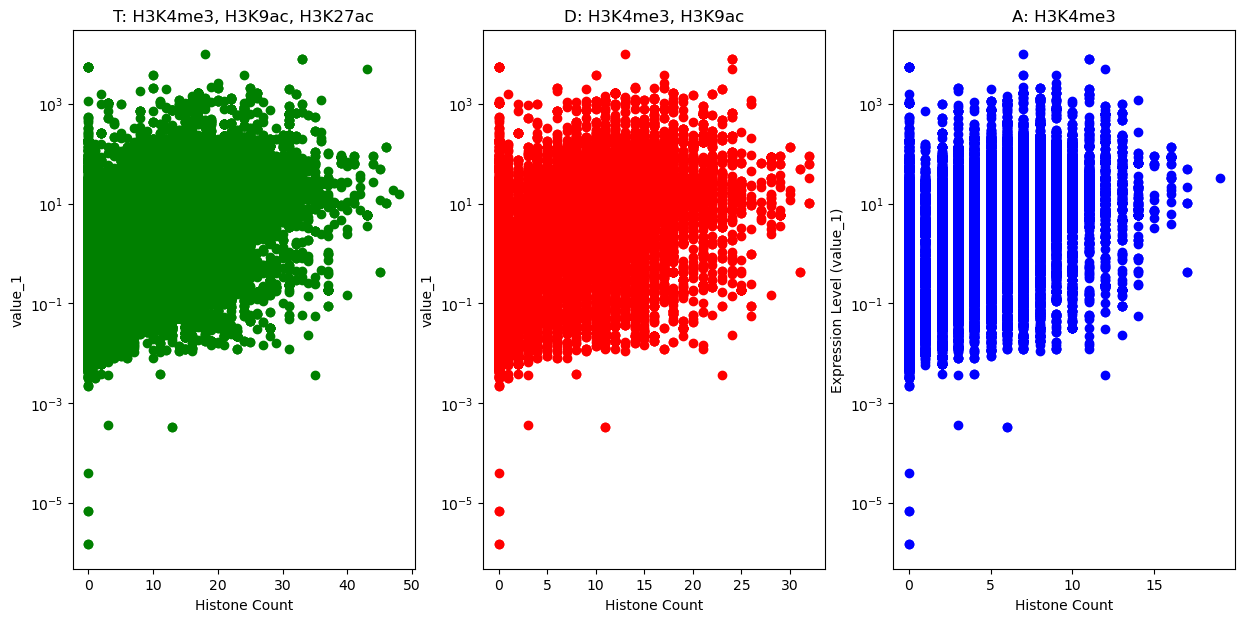

In [33]:
fig, axes = plt.subplots(nrows = 1, ncols=3, figsize = (15, 7))

# T
axes[0].scatter(histone_count_df[['T']], histone_count_df[['value_1']], c='green')
axes[0].set_yscale('log', base=10)
axes[0].set_title("T: H3K4me3, H3K9ac, H3K27ac")
axes[0].set_xlabel("Histone Count")
axes[0].set_ylabel("value_1")

# D
axes[1].scatter(histone_count_df[['D']], histone_count_df[['value_1']], c='red')
axes[1].set_yscale('log', base=10)
axes[1].set_title("D: H3K4me3, H3K9ac")
axes[1].set_xlabel("Histone Count")
axes[1].set_ylabel("value_1")

# A
axes[2].scatter(histone_count_df[['A']], histone_count_df[['value_1']], c='blue')
axes[2].set_yscale('log', base=10)
axes[2].set_title("A: H3K4me3")
axes[2].set_xlabel("Histone Count")
axes[2].set_ylabel("Expression Level (value_1)")


plt.show()

In [34]:
sql = "SELECT T, value_1 \
		FROM common.tda \
        WHERE T <= 6"

t_df = pd.read_sql_query(sql, engine)

display(t_df.head())
display(t_df.shape)

,T,value_1
0,0,0.000000
1,0,0.047392
2,0,0.000000
3,0,2.468570
4,0,2.468570


(27752, 2)

In [44]:
min(t_df['T'])

0

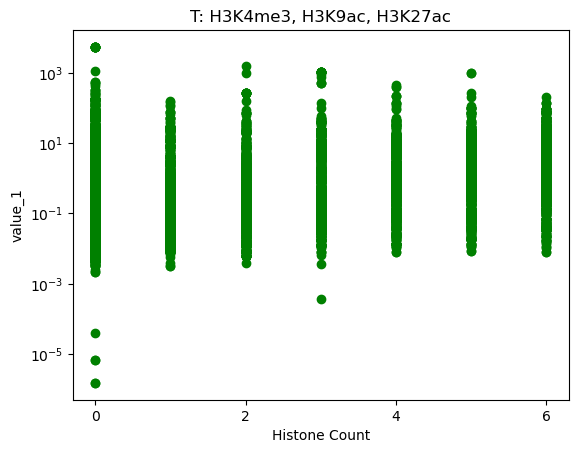

In [45]:
x = t_df['T']

plt.scatter(t_df[['T']], t_df[['value_1']], c='green')
plt.yscale('log', base=10)
plt.title("T: H3K4me3, H3K9ac, H3K27ac")
plt.xlabel("Histone Count")
plt.xticks(np.arange(int(min(x)), int(max(x)) + 1, 2))
plt.ylabel("value_1")
plt.show()